# Exercise 11: The beauty of kNN

In this exercise, you'll gain practice working with kNN. We'll use the [diamonds](https://ggplot2.tidyverse.org/reference/diamonds.html) dataset, which comes as part of `ggplot2`. This dataset provides information on the quality and price of 50,000 diamonds.


-----
## 1. Data, Plotting, and Train/Test Sets (2 points)
* Load the the `class` and `tidyverse` packages.
* Assign the `diamonds` data set to a simpler name. Then, create a new variable `price_bin` that splits the `price` variable into a binary variable, where 1 indicates that the diamond costs greater than the mean price, and 0 indicates that the diamond costs less than the mean price. Set `price_bin` to be a factor. (*Hint: use the if_else() function*)
* Select just the `carat`, `depth`, `table`, `x`, `y`, and your new `price_bin` variables
* Print the first few lines of the data set
* Print the dimensions of the data set


In [30]:
library(class)
library(tidyverse)
data <- diamonds

#mean(data$price)
data <- data %>% #add new column that bins prices into lower and higher than mean
    mutate(price_bin = if_else(price < mean(price), 0, 1))

new_data <- select(data, carat, depth, table, x, y, price_bin) #select subset of varibales
head(new_data,10)
dim(new_data)

carat,depth,table,x,y,price_bin
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.23,61.5,55,3.95,3.98,0
0.21,59.8,61,3.89,3.84,0
0.23,56.9,65,4.05,4.07,0
0.29,62.4,58,4.20,4.23,0
0.31,63.3,58,4.34,4.35,0
0.24,62.8,57,3.94,3.96,0
0.24,62.3,57,3.95,3.98,0
0.26,61.9,55,4.07,4.11,0
0.22,65.1,61,3.87,3.78,0


[1] 53940     6

### Plot
Create a scatterplot of the link between `carat` and `depth`, and use the `color` aesthetics mapping to differentiate between diamonds that cost above versus below the mean price.

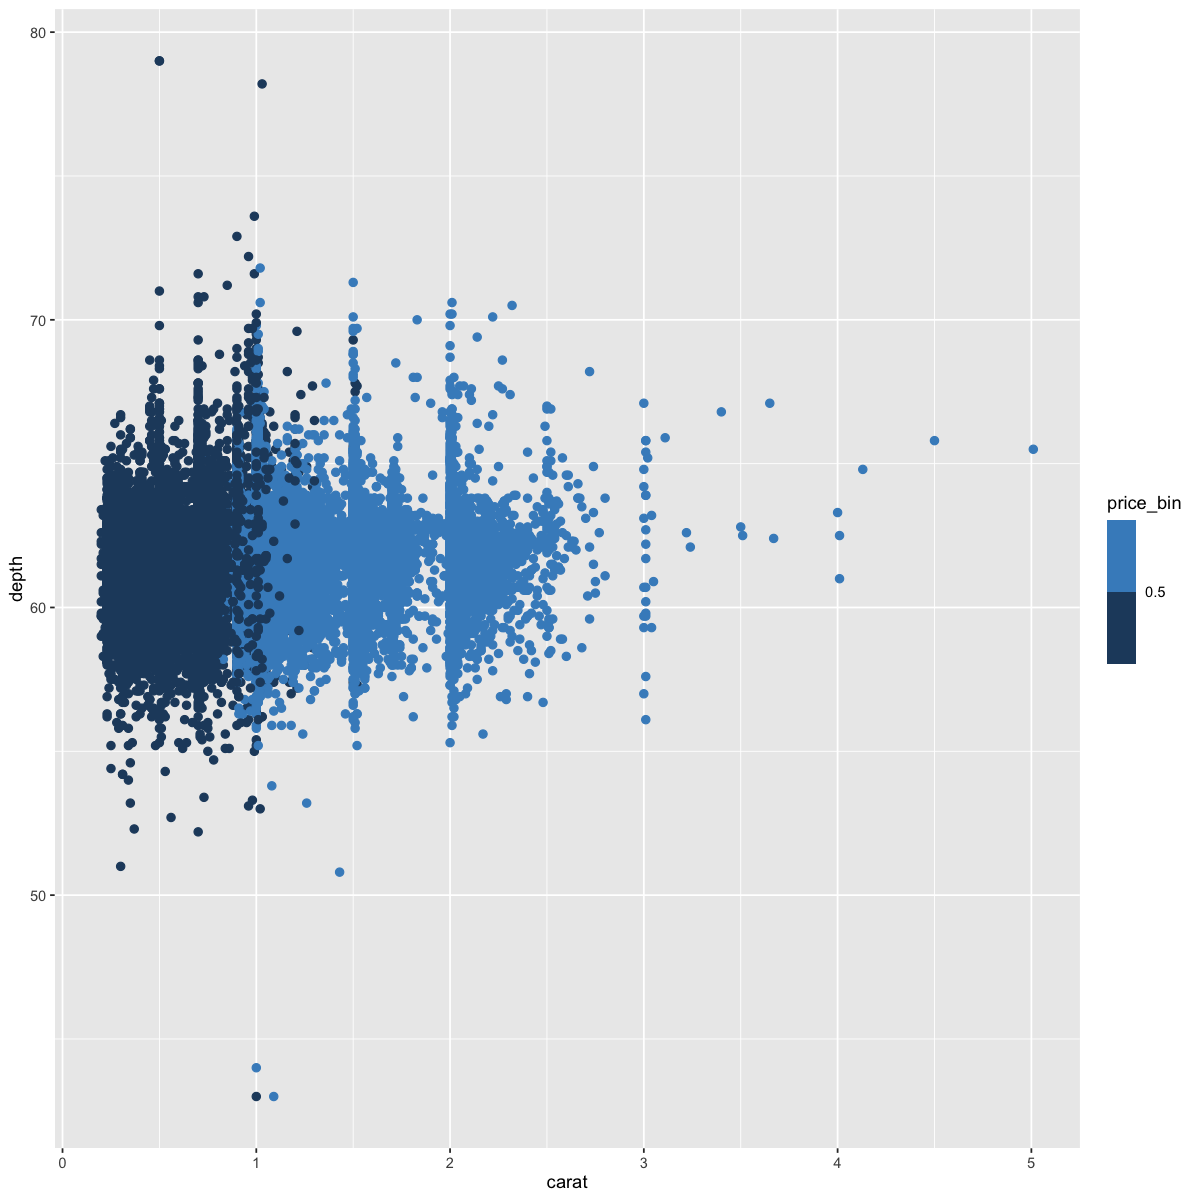

In [37]:
ggplot(data,aes(x=carat,y=depth,col=price_bin)) +
 geom_point(size=2) + 
 scale_color_binned(n.breaks = 3)

Based on the above scatterplot, how do you think kNN will perform using only these two variables to predict price? Which variable, carat or depth, gives us the most information about which price class the diamond will belong to?
> * I think KNN will perform well for carat values well below and well above 1, but it will struggle to predict high vs. low price when at the boundary, or when carat = 1.
> * Carat, rather than depth, gives us more information about the diamond's price class, since the two price clusters are divided across the carat dimension. 

### Test vs Train

Before we run KNN on these data, we need to set aside a portion of the observations as our test set. Below, randomly divide the data such that 30% are allotted to the `test` set and the rest are allotted to the `train` set. Print the first few lines of each set, and print the dimensions of each set to double check your division of the data.

In [49]:
set.seed(2023)

#nrow(data)*0.3

#pull random sample of 30% of row indices
test.inds <- sample(1:nrow(data), nrow(data)*0.3)

test_set <- cbind(data$carat[test.inds], data$depth[test.inds])
dim(test_set)
head(test_set, 10)
train_set <- cbind(data$carat[-test.inds], data$depth[-test.inds])
dim(train_set)
head(train_set, 10)


[1] 16182     2

1.22,62.3
1.57,62.3
1.11,62.4
0.42,60.6
0.32,62.6
0.90,62.7
1.09,62.5
0.53,62.2
0.23,60.4
0.55,61.3


[1] 37758     2

0.23,61.5
0.23,56.9
0.29,62.4
0.31,63.3
0.24,62.8
0.24,62.3
0.26,61.9
0.22,65.1
0.23,59.4
0.23,62.8


-----
## 2. KNN (3 points)
Now, use the `knn()` function from the `class` library to predict `price_bin` from the `carat` and `depth`. Set `k = 3`.

*Hint: Review the format required for the arguments of knn()*

In [52]:
set.seed(2023)
train_spec <- data$price_bin[-test.inds]

test.spec.knn <- knn(train_set, test_set, train_spec, k =3)

[1] 1 1 1 0 0 1 1 0 0 0
Levels: 0 1

Now, output a confusion matrix and calculate the test error to evaluate model performance.

In [56]:
# new variable for each observation's predicted species. 
data$price_bin_pred <- data$price_bin

# add the KNN predictions for test obs to dataset.
data$price_bin_pred[test.inds] <- test.spec.knn

# in which cases does the observed Species equal the predicted?
data$KNN_correct <- data$price_bin == data$price_bin_pred

confusion_df <- data.frame(predicted = test.spec.knn,actual = data$price_bin[test.inds])
table(confusion_df)
print("---")
print(paste("Accuracy:",mean(confusion_df$predicted == confusion_df$actual)))


         actual
predicted    0    1
        0 9707  316
        1  539 5620

[1] "---"
[1] "Accuracy: 0.947163515016685"


How did your model perform?
> * My model performed quite well, with an accuracy of 94.7%

Let's try to improve our model by adding all of the other variables in our data set as predictors. Rerun your `knn()` below, keeping `k = 3`. Again, output a confusion matrix and error rate for your updated model fit.

In [60]:
set.seed(2023)
#add the other variables as predictors
test_set <- cbind(data$carat[test.inds], data$depth[test.inds], data$table[test.inds], data$x[test.inds], data$y[test.inds]) 
train_set <- cbind(data$carat[-test.inds], data$depth[-test.inds], data$table[-test.inds], data$x[-test.inds], data$y[-test.inds])

train_spec <- data$price_bin[-test.inds]
test.spec.knn <- knn(train_set, test_set, train_spec, k =3)

#calculate which price bins kNN predicted correctly
data$price_bin_pred <- data$price_bin
data$price_bin_pred[test.inds] <- test.spec.knn
data$KNN_correct <- data$price_bin == data$price_bin_pred

confusion_df <- data.frame(predicted = test.spec.knn,actual = data$price_bin[test.inds])
table(confusion_df)
print("---")
print(paste("Accuracy:",mean(confusion_df$predicted == confusion_df$actual)))


         actual
predicted    0    1
        0 9728  391
        1  518 5545

[1] "---"
[1] "Accuracy: 0.943826473859844"


Did your model predictions improve?
> * The accuracy seems not to have improved -- it stayed the same. 

-----
## 3. For loop (3 points)

So adding additional predictors didn't shift our error much. Let's see if adjusting `k` has a larger impact on model accuracy.

Using your initial model above with just `carat` and `depth`, run a `for loop` that runs the same model 30 times, for `k = 1:30`.

Output a data frame that has `k` and the overall `error` as columns.

The structure of the output data frame and `for loop` are provided for you below. Note that your loop will take a minute or two to run because there are so many observations in the dataset. It may be helpful while you are writing and testing your loop to run it on a subset of the data with only a handful of rows.

In [66]:
# this is provided
# setting up empty table to store for loop output
output  <- data.frame(k = seq(1:30),
                     error = rep(NA, 30))
head(output)

,k,error
,<int>,<lgl>
1,1,NA
2,2,NA
3,3,NA
4,4,NA
5,5,NA
6,6,NA


In [67]:
set.seed(2023)
test.inds <- sample(1:nrow(data), nrow(data)*0.3)
test_set <- cbind(data$carat[test.inds], data$depth[test.inds])
train_set <- cbind(data$carat[-test.inds], data$depth[-test.inds])
train_spec <- data$price_bin[-test.inds]
data$price_bin_pred <- data$price_bin
#data$price_bin_pred[test.inds] <- test.spec.knn

test.spec.knn <- knn(train_set, test_set, train_spec, k =3)
#****** 
data$price_bin_pred <- data$price_bin


In [79]:
for (k in seq(1:30)) {
    knn_fits  <- knn(train_set, test_set, train_spec, k)
    #overall error
    conf_df  <- data.frame(predicted = knn_fits,actual = data$price_bin[test.inds])
    # data frame of test predictions versus actual test
    output$error[k]  <- 1 - mean(conf_df$predicted == conf_df$actual)
    #calculate error from conf_df and add to your output dataframe
}
head(output, 30)

,k,error
,<int>,<dbl>
1,1,0.05419602
2,2,0.05456680
3,3,0.05370164
4,4,0.05394883
5,5,0.05228031
6,6,0.05246570
7,7,0.05197133
8,8,0.05172414
9,9,0.05129156


Create a line plot of your `output` object using `ggplot`. Add a (non-linear) `geom_smooth` layer.

Warning message:
“Use of `output$k` is discouraged.
ℹ Use `k` instead.”
Warning message:
“Use of `output$error` is discouraged.
ℹ Use `error` instead.”
Warning message:
“Use of `output$k` is discouraged.
ℹ Use `k` instead.”
Warning message:
“Use of `output$error` is discouraged.
ℹ Use `error` instead.”
`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


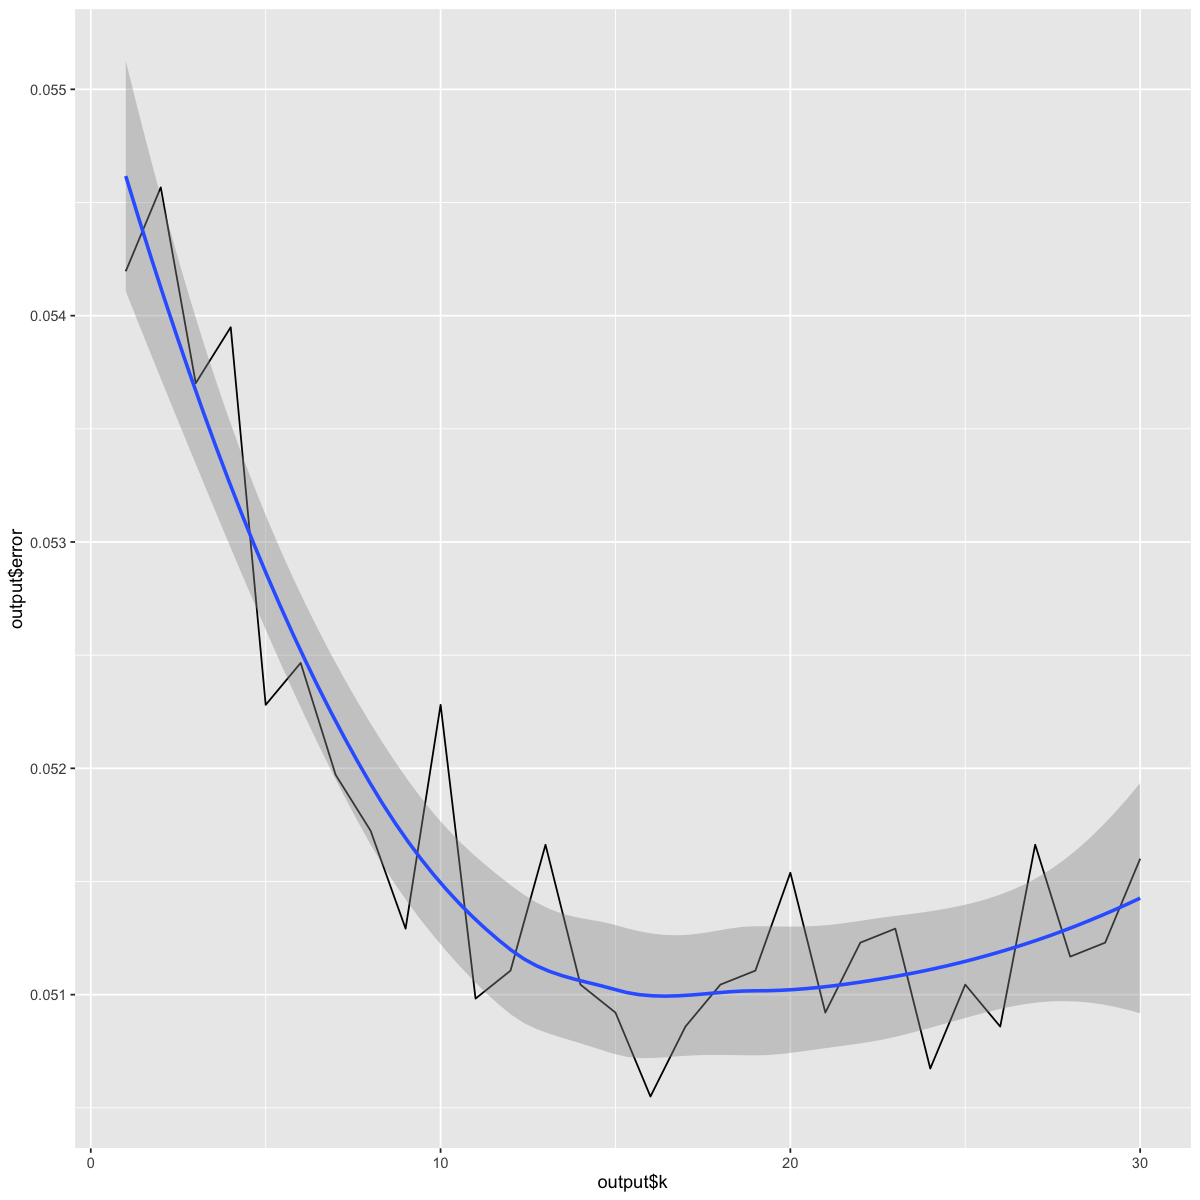

In [80]:
ggplot(data = output, aes(x = output$k, y = output$error)) +
    geom_line() + 
    geom_smooth()
    
    
        
      

Interpret your plot. What would you select as the best value of `k`? How much does this improve your test error?
> * As the best value of k, I would select 16. However, the test error is improved very marginally -- the difference between the biggest erro at k=2 and smallest error at k=16 is 0.0004 


-----
## 4. Standardizing predictors (2 points)

Because knn is based on distances between points, it is very sensitive to the scale of your variables. Looking at our predictor variables, we can see that `carat` and `depth` are orders of magnitude different in terms of scales. Maybe we can improve our fit even more by addressing this!

Below, use the `scale()` function to standardize your predictors. (Note that you don't need to standardize `price_bin`.)

Then, run your model a final time with your standardized predictors (just `carat` and `depth` still). Set `k` to the optimal value you determined in your plot above. Output the confusion matrix and error rate again.

In [82]:
set.seed(2023)

carat_s <- scale(data$carat)
depth_s <- scale(data$depth) 

test_set <- cbind(carat_s[test.inds], depth_s[test.inds])
train_set <- cbind(carat_s[-test.inds], depth_s[-test.inds])

train_spec <- data$price_bin[-test.inds]
test.spec.knn <- knn(train_set, test_set, train_spec, k =16)

#calculate which price bins kNN predicted correctly
data$price_bin_pred <- data$price_bin
data$price_bin_pred[test.inds] <- test.spec.knn
data$KNN_correct <- data$price_bin == data$price_bin_pred

confusion_df <- data.frame(predicted = test.spec.knn,actual = data$price_bin[test.inds])
table(confusion_df)
print("---")
print(paste("Accuracy:",mean(confusion_df$predicted == confusion_df$actual)))

         actual
predicted    0    1
        0 9722  288
        1  524 5648

[1] "---"
[1] "Accuracy: 0.949820788530466"


What impact did rescaling the data have on your error rate?
> * It slightly improved the error rate.


**DUE:** 11:59pm March 17, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *Someone's Name*
>
>


**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.

For help with data frame syntax (column addition), I asked chatGPT the following: 
I am trying to add a new column to data, but using the following syntax, the new column (price_bin) is not concatenated to data. How can I change the syntax so price_bin is added to data? data %>% mutate(price_bin = if_else(price < mean(price), 0, 1))